Author: Catherine Gatt

Date: 24/02/2026

Content: 
Scanpy-based workflow used to process, normalise, and cluster single-cell RNA-seq data from queen, king, soldier, and worker castes of Zootermopsis nevadensis.

In [1]:
print('hello')
import pandas as pd
import scanpy as sc

hello


In [10]:
print(sc.__version__)
import sys
print("Python version")
print(sys.version)

1.11.1
Python version
3.12.2 | packaged by Anaconda, Inc. | (main, Feb 27 2024, 17:35:02) [GCC 11.2.0]


In [1]:
matrix = "/home/catherine/phd/projects/termites/data/oist_matrices/znev_castes_combined_craggr_no_norm"

In [3]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor="white")
# apparently not important 

In [4]:
adata = sc.read_10x_mtx(
    matrix,  # the directory with the `.mtx` file
    var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
    #cache=True,  # write a cache file for faster subsequent reading
)
# dont really have to use cahe - fabio never has 

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.


In [5]:
print(adata.var["gene_ids"])

Znev00005426    Znev00005426
Znev00005427    Znev00005427
Znev00005428    Znev00005428
Znev00005429    Znev00005429
Znev00005430    Znev00005430
                    ...     
Znev00014255    Znev00014255
Znev00014250    Znev00014250
Znev00014246    Znev00014246
Znev00014270    Znev00014270
Znev00014265    Znev00014265
Name: gene_ids, Length: 14272, dtype: object


In [131]:
adata.obs_names

Index(['AAACCCATCACATACG-1', 'AAACCCATCGACCAAT-1', 'AAACGAAAGGCCACCT-1',
       'AAACGAACACTTCAAG-1', 'AAACGAATCCATTTAC-1', 'AAACGAATCGATTGAC-1',
       'AAACGCTCAGAGAAAG-1', 'AAAGAACAGTCAGCCC-1', 'AAAGAACGTATATGGA-1',
       'AAAGAACGTATGTCAC-1',
       ...
       'TTTGGTTTCCACGTCT-4', 'TTTGTTGAGAGGGTAA-4', 'TTTGTTGAGGTTAGTA-4',
       'TTTGTTGAGTAGAATC-4', 'TTTGTTGAGTGACACG-4', 'TTTGTTGAGTGATAAC-4',
       'TTTGTTGCACGACAGA-4', 'TTTGTTGCAGCATACT-4', 'TTTGTTGTCATAGGCT-4',
       'TTTGTTGTCCTCGATC-4'],
      dtype='object', length=24252)

In [6]:
adata.obs['sample#'] = adata.obs_names.str.split('-', expand=True).get_level_values(1)

In [7]:
adata.obs['caste'] = adata.obs['sample#'].map({
         '1': 'king',
         '2': 'queen',
         '3': 'soldier',
         '4': 'worker',
     })

In [8]:
adata.obs['caste']

AAACCCATCACATACG-1      king
AAACCCATCGACCAAT-1      king
AAACGAAAGGCCACCT-1      king
AAACGAACACTTCAAG-1      king
AAACGAATCCATTTAC-1      king
                       ...  
TTTGTTGAGTGATAAC-4    worker
TTTGTTGCACGACAGA-4    worker
TTTGTTGCAGCATACT-4    worker
TTTGTTGTCATAGGCT-4    worker
TTTGTTGTCCTCGATC-4    worker
Name: caste, Length: 24252, dtype: object

In [135]:
# scanpy tutorial [6] suggests doing this. what this is doing is seeing if there is more than one gene and associated counts with 
# the same name. This happens when the gene name is the same but present at two seperate coordinates
# scanpy has a function that just makes the gene names unique, however, you should probably just combine the genes into one and combine 
# the read counts. So instead of just running this line, below I am checking is there are any gene symbols that are the same.

#adata.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`

In [9]:
print((adata.var_names).nunique())
print((adata.var_names).size)
# check if all gene symbols are unique, if they are not merge the ones that are not unique 

14272
14272


In [137]:
adata

AnnData object with n_obs × n_vars = 24252 × 14272
    obs: 'sample#', 'caste'
    var: 'gene_ids', 'feature_types'

Preprocessing:
Show those genes that yield the highest fraction of counts in each single cell, across all cells.



normalizing counts per cell


    finished (0:00:00)


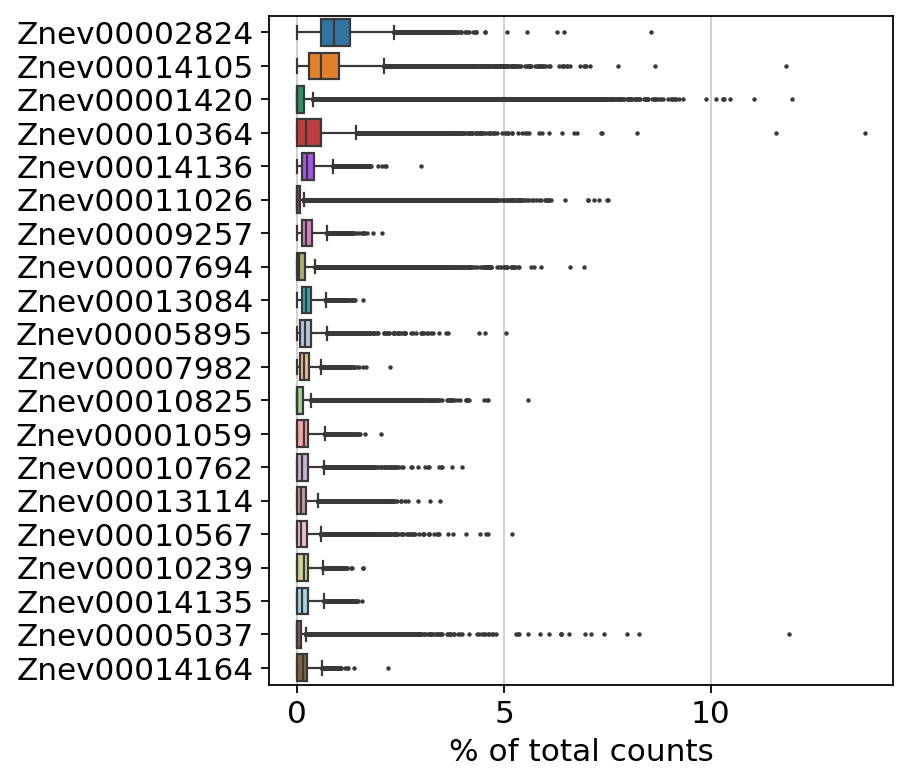

In [138]:
sc.pl.highest_expr_genes(adata, n_top=20)
# we are checking the most expressed genes in each cell. we are expecting to see some:
# - artifacts 


In [140]:
# annotate the group of mitochondrial genes as "mt"
sc.pp.calculate_qc_metrics(
    adata, percent_top=None, log1p=False, inplace=True
)

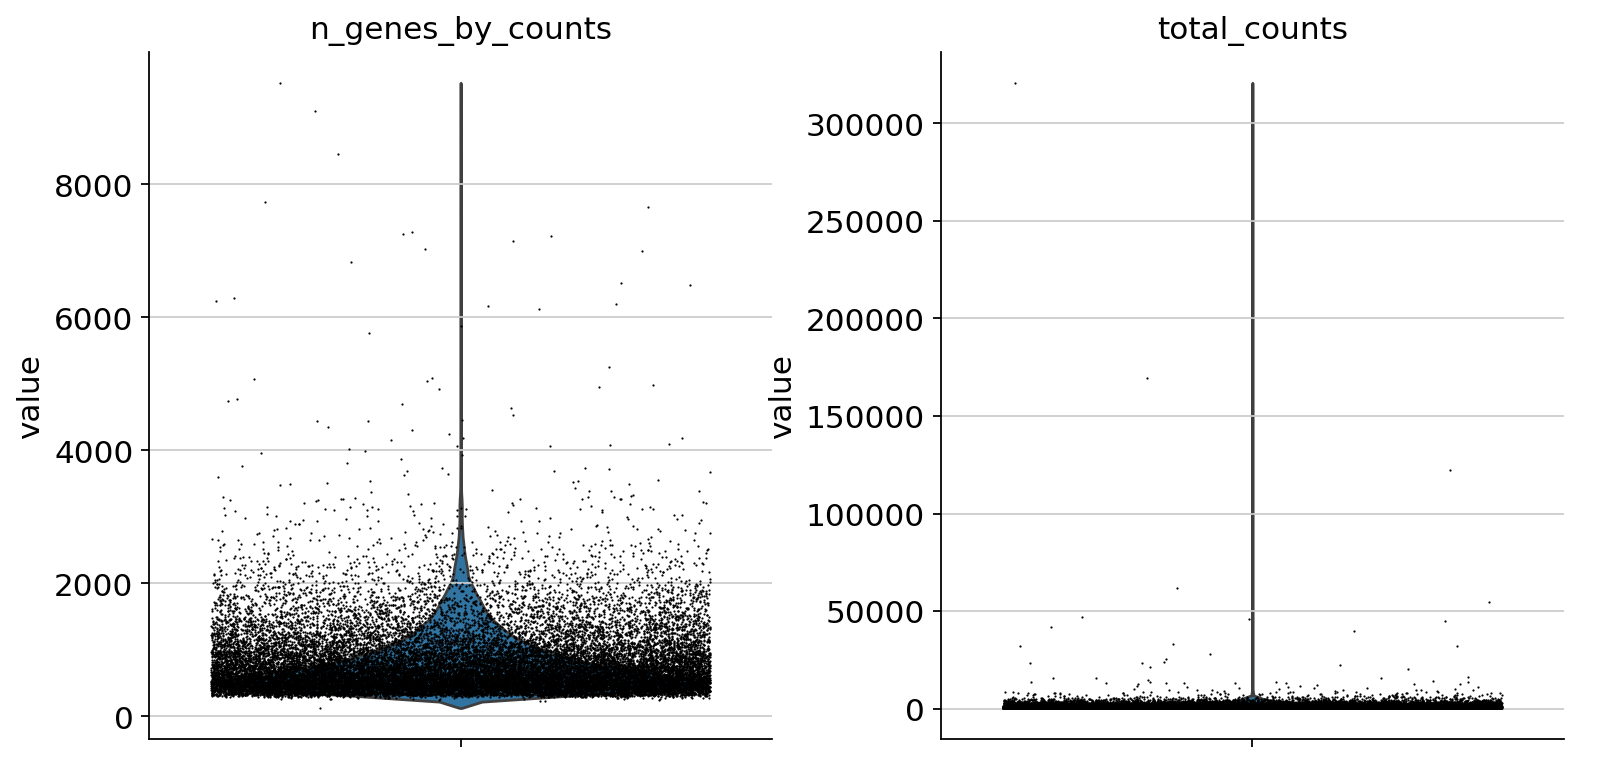

In [141]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

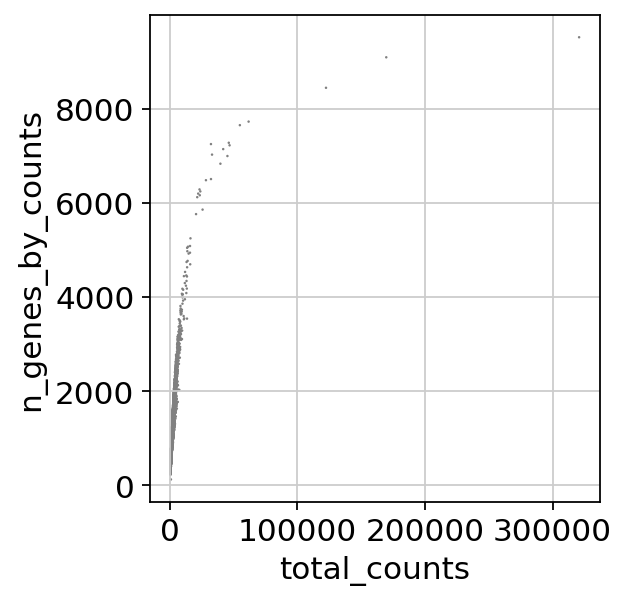

In [142]:

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [143]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell


    finished (0:00:00)


In [144]:
sc.pp.log1p(adata)

In [145]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]


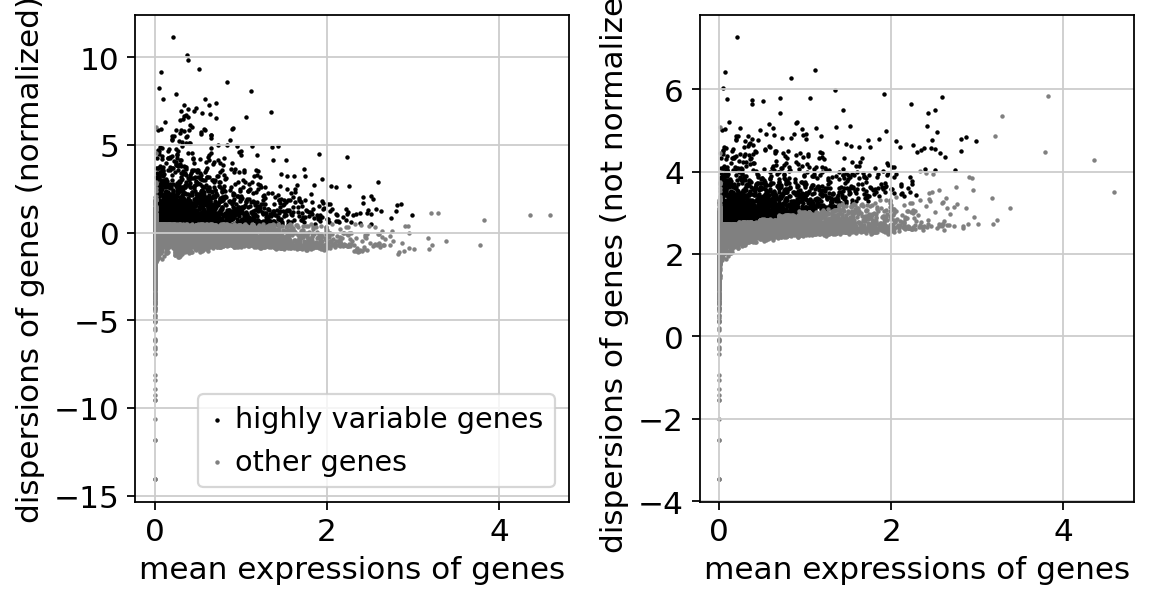

In [146]:
sc.pl.highly_variable_genes(adata)

In [147]:
sc.tl.pca(adata, svd_solver="arpack")

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)


In [148]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [149]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)


In [150]:
sc.tl.leiden(
    adata,
    resolution=0.9,
    random_state=0,
    n_iterations=2,
    directed=False,
)

running Leiden clustering
    finished: found 33 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)


In [151]:
adata

AnnData object with n_obs × n_vars = 24252 × 14272
    obs: 'sample#', 'caste', 'n_genes_by_counts', 'total_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


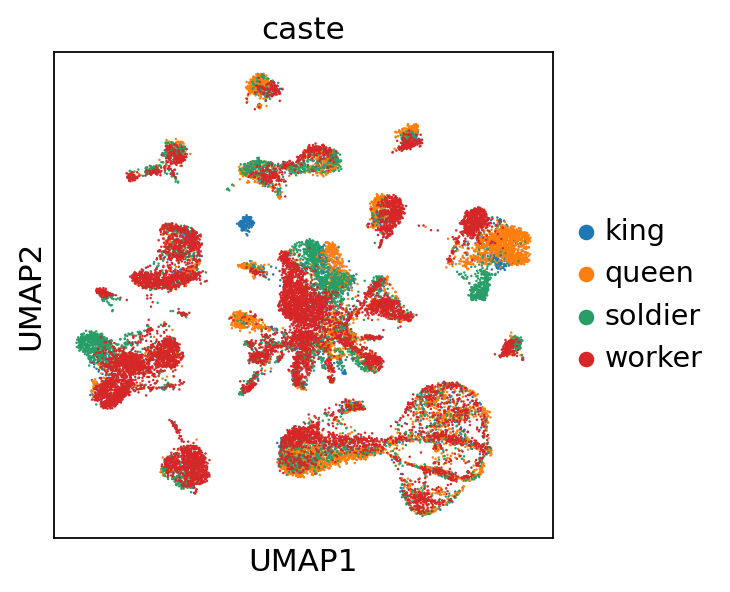

/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


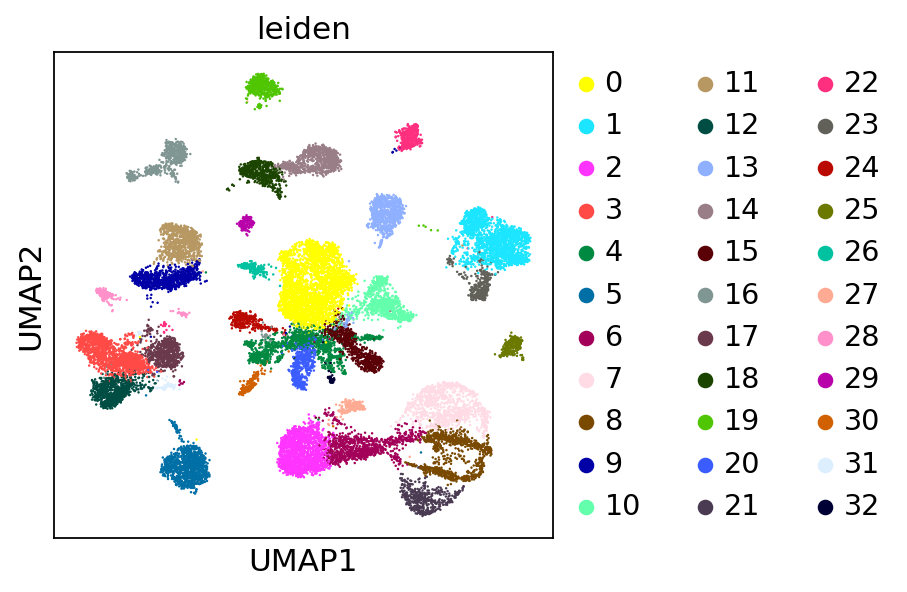

In [152]:
sc.pl.umap(adata, color=["caste"])
sc.pl.umap(adata, color=["leiden"])

ranking genes


/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:15)


/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/home/catherine/anaconda3/envs/sc_termites/lib/python3.12/site-packages/scanpy/tools/_rank_gene

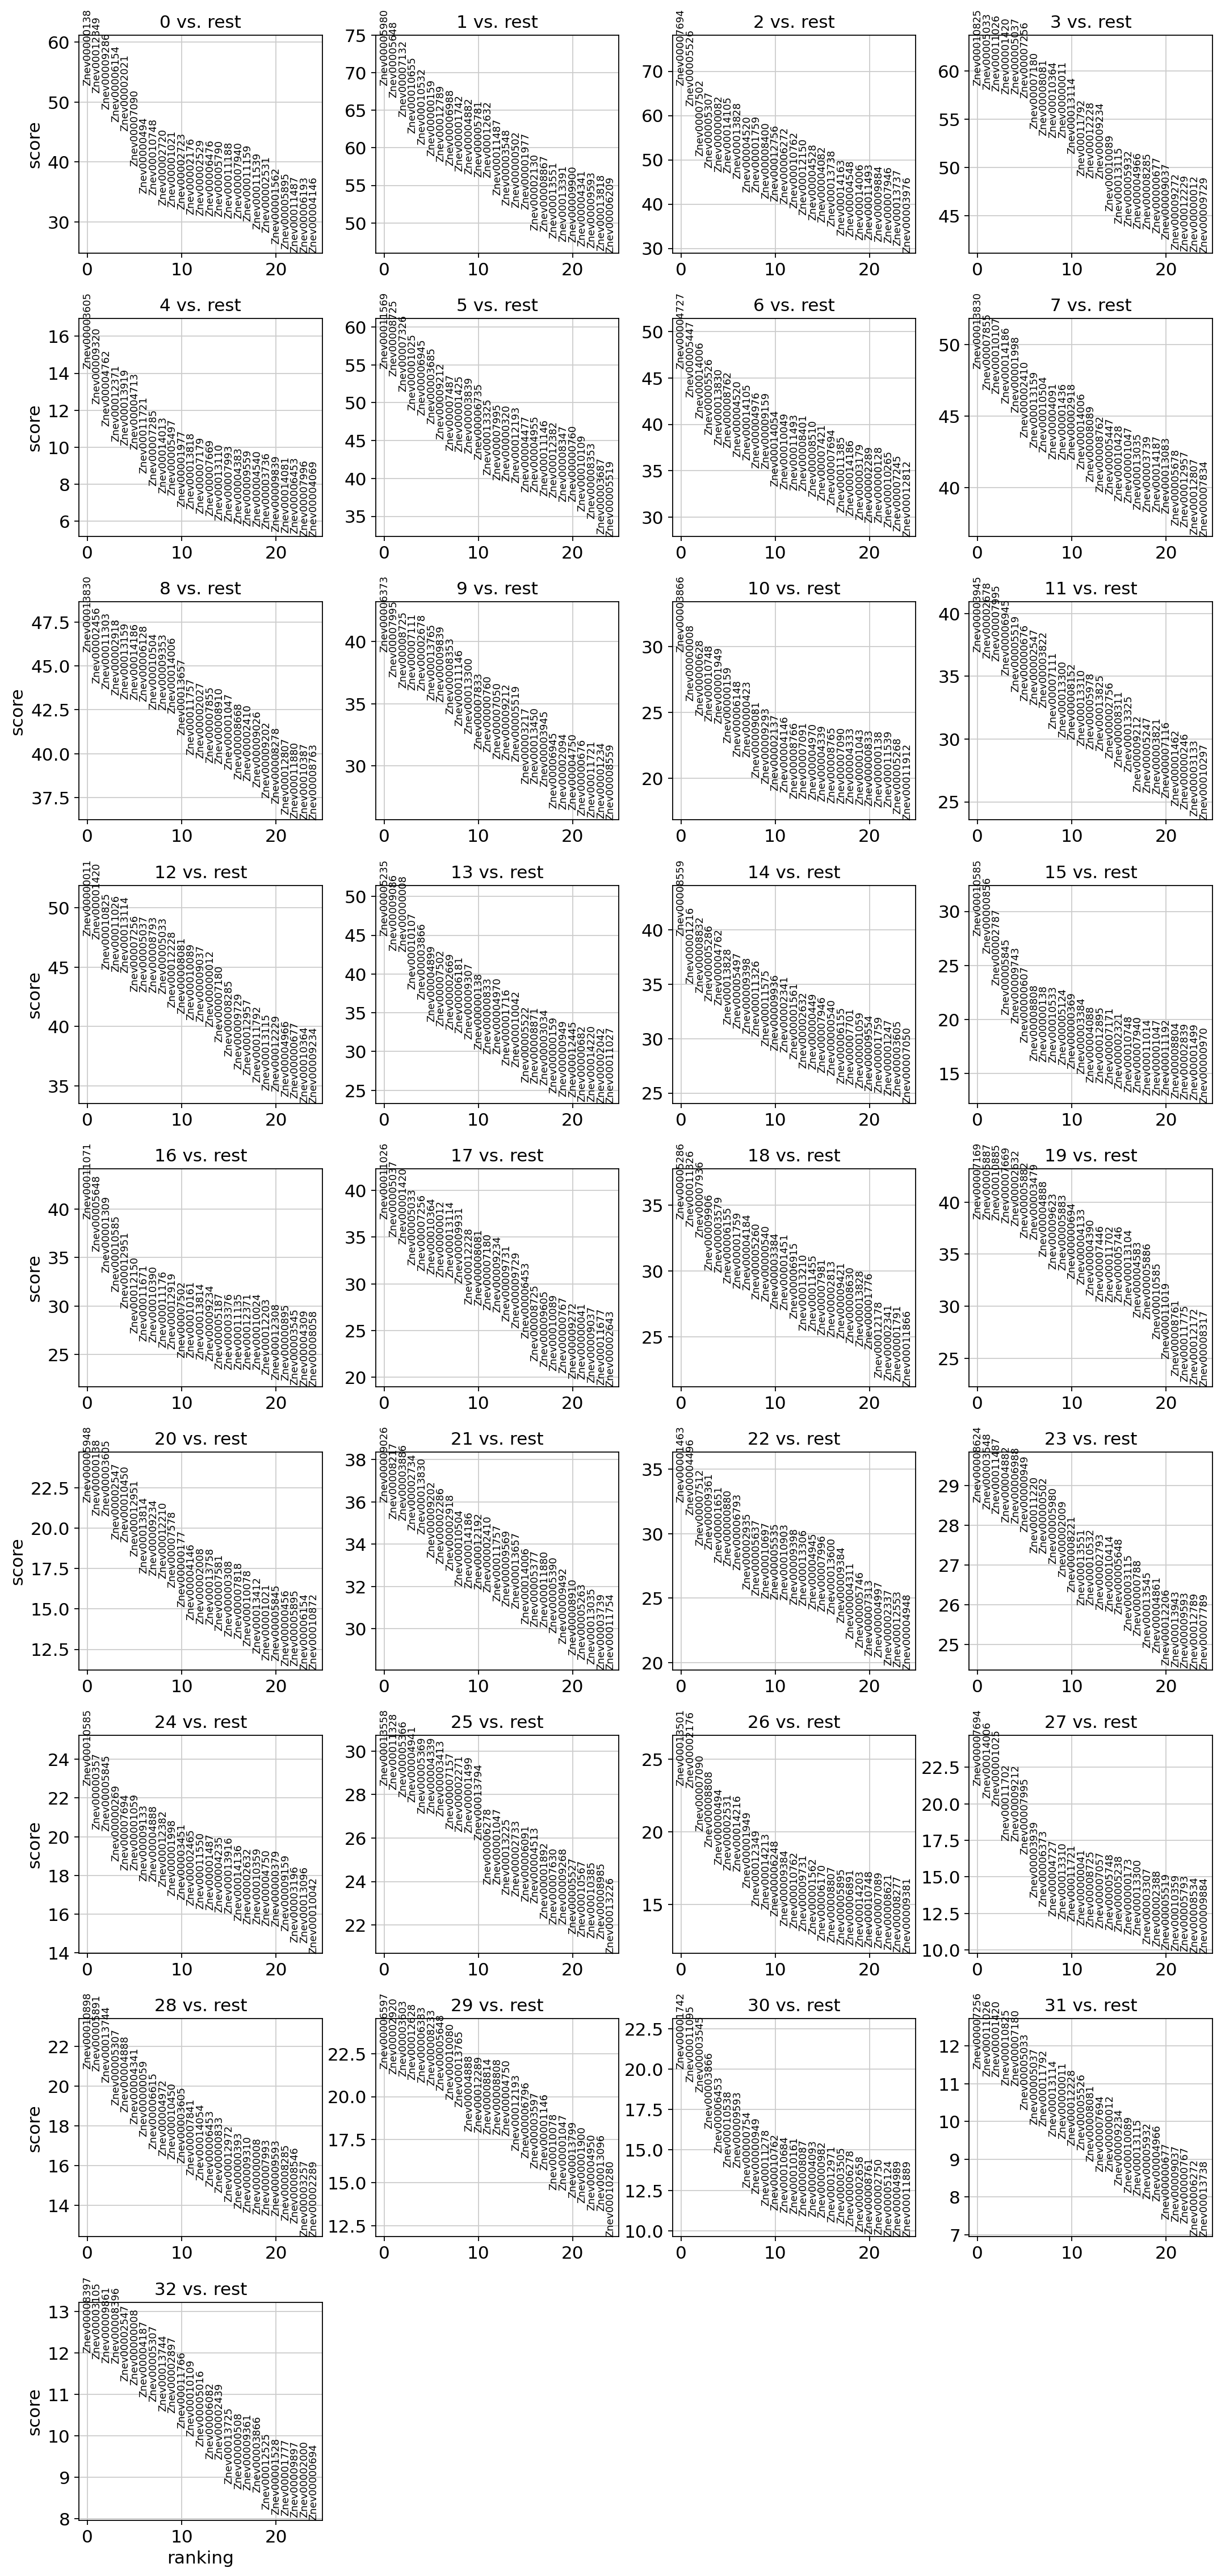

In [153]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [154]:
pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(5)

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,Znev00000138,Znev00005980,Znev00007694,Znev00010825,Znev00003605,Znev00011569,Znev00004727,Znev00013830,Znev00013830,Znev00006373,...,Znev00008624,Znev00010585,Znev00013558,Znev00013501,Znev00007694,Znev00010898,Znev00006597,Znev00001742,Znev00007256,Znev00008397
1,Znev00012349,Znev00005648,Znev00005526,Znev00005033,Znev00009320,Znev00008725,Znev00005447,Znev00007855,Znev00002456,Znev00007995,...,Znev00003548,Znev00000357,Znev00011328,Znev00002176,Znev00014006,Znev00005891,Znev00002920,Znev00011095,Znev00011026,Znev00003105
2,Znev00009286,Znev00007132,Znev00007502,Znev00011026,Znev00004762,Znev00007326,Znev00014006,Znev00010107,Znev00011303,Znev00008725,...,Znev00011487,Znev00005845,Znev00005366,Znev00007090,Znev00001025,Znev00013744,Znev00003603,Znev00003545,Znev00001420,Znev00009861
3,Znev00006154,Znev00010655,Znev00005307,Znev00001420,Znev00012371,Znev00001025,Znev00005526,Znev00014186,Znev00002918,Znev00007111,...,Znev00004882,Znev00000269,Znev00004941,Znev00008808,Znev00011702,Znev00005307,Znev00012628,Znev00003866,Znev00010825,Znev00008396
4,Znev00002021,Znev00010532,Znev00000082,Znev00005037,Znev00013919,Znev00006945,Znev00013830,Znev00001998,Znev00013159,Znev00002678,...,Znev00006988,Znev00007694,Znev00005369,Znev00000494,Znev00009212,Znev00004888,Znev00006383,Znev00006453,Znev00007180,Znev00002547


In [155]:
print(adata.var["feature_types"])
adata

Znev00005426    Gene Expression
Znev00005427    Gene Expression
Znev00005428    Gene Expression
Znev00005429    Gene Expression
Znev00005430    Gene Expression
                     ...       
Znev00014255    Gene Expression
Znev00014250    Gene Expression
Znev00014246    Gene Expression
Znev00014270    Gene Expression
Znev00014265    Gene Expression
Name: feature_types, Length: 14272, dtype: category
Categories (1, object): ['Gene Expression']


AnnData object with n_obs × n_vars = 24252 × 14272
    obs: 'sample#', 'caste', 'n_genes_by_counts', 'total_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'caste_colors', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [156]:
top_genes = pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(1)
top_genes.values.tolist()


[['Znev00000138',
  'Znev00005980',
  'Znev00007694',
  'Znev00010825',
  'Znev00003605',
  'Znev00011569',
  'Znev00004727',
  'Znev00013830',
  'Znev00013830',
  'Znev00006373',
  'Znev00003866',
  'Znev00003945',
  'Znev00000011',
  'Znev00005235',
  'Znev00008559',
  'Znev00010585',
  'Znev00011071',
  'Znev00011026',
  'Znev00005286',
  'Znev00007169',
  'Znev00005948',
  'Znev00009026',
  'Znev00001463',
  'Znev00008624',
  'Znev00010585',
  'Znev00013558',
  'Znev00013501',
  'Znev00007694',
  'Znev00010898',
  'Znev00006597',
  'Znev00001742',
  'Znev00007256',
  'Znev00008397']]

In [157]:
results_file = "../data/znev/combined_no_norm_clustered.h5ad"
adata.write(results_file)